# **Feature Transformations**
### **Purpose of Transformation**
 - 1. Reduce Skewness 
 - 2. Handle Outliers
### **Methods:**
- 1. Log Transformation
- 2. Box-cox / Yeo-Johnson
### **Outliers:**
- Exreme values that lie far from the main data distribution & can negatively affect machine learning model performance.
### **Methods:**
- 1. Clipping
- 2. Winsorization
------------------------------

# 1. Import & Load Dataset

In [14]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Load dataset - telecom churn
df = pd.read_csv("../datasets/telecom_churn.csv")

# display dataset
df.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


# 2. See the Problem

In [16]:
# display stat.
df[["monthly_income", "monthly_bill"]].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


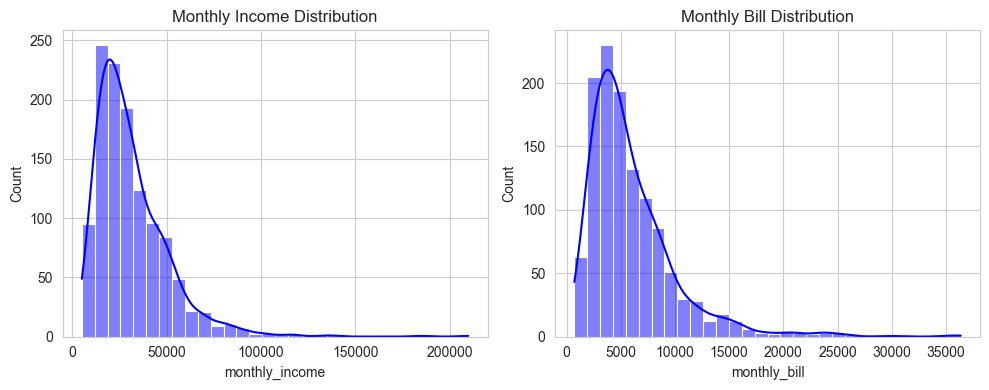

In [17]:
# Histogram to check skewness
sns.set_style("whitegrid")
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["monthly_income"], kde = True, bins = 30, color = "blue")
plt.title("Monthly Income Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["monthly_bill"], kde = True, bins = 30, color = "blue")
plt.title("Monthly Bill Distribution")
plt.tight_layout()

plt.show()

### This shows:
- Max > Mean
- Strong Skew present
- Ideal candidate for transformation

# 3. Log Transformation

In [19]:
df["income_log"] = np.log1p(df["monthly_income"])
df[["monthly_income", "income_log"]].head()

,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


## 3.1: Compare Plots - monthly_income & income_log

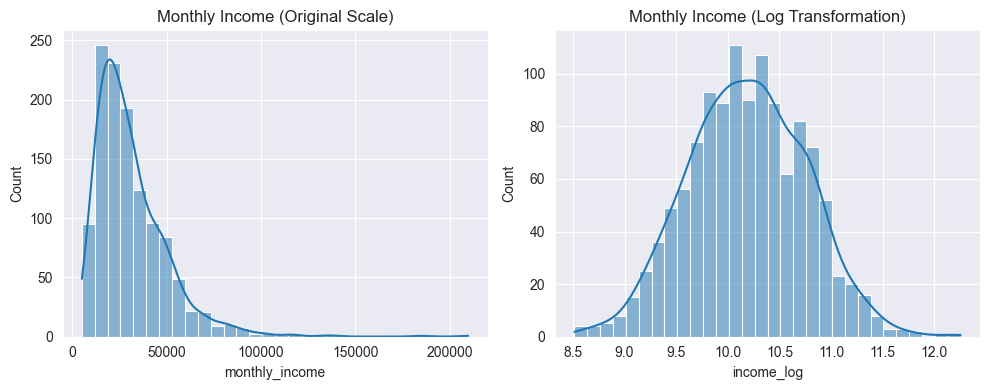

In [20]:
sns.set_style("darkgrid")
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
sns.histplot(data = df, x = "monthly_income", kde = True, bins = 30)
plt.title("Monthly Income (Original Scale)")

plt.subplot(1, 2, 2)
sns.histplot(data = df, x = "income_log", kde = True, bins = 30)
plt.title("Monthly Income (Log Transformation)")
plt.tight_layout()
plt.show()

# 3.2 Before vs After

In [22]:
df[["monthly_income", "income_log"]].describe()

,monthly_income,income_log
count,1200.000000,1200.000000
mean,31155.975833,10.185955
std,19351.937726,0.566190
min,4984.000000,8.514189
25%,17795.000000,9.786729
50%,26628.000000,10.189755
75%,39886.250000,10.593811
max,209790.000000,12.253867


# 4. Treatment of Outliers

## 4.1 Clipping

In [26]:
# Specify the upper boundary at the 99th percentile
upper_limit = df["monthly_bill"].quantile(0.99)

# Clip values above the upper limit
df["bill_clipped"] = df["monthly_bill"].clip(
    upper=upper_limit
)

# Compare the maximum and middle observations
df.loc[
    [
        df["monthly_bill"].idxmax(),
        df["monthly_bill"].sort_values().index[len(df) // 2]
    ],
    ["monthly_bill", "bill_clipped"]
]

,monthly_bill,bill_clipped
968,36361.0,21696.4
47,4873.0,4873.0


## 4.2 Comparison Plot

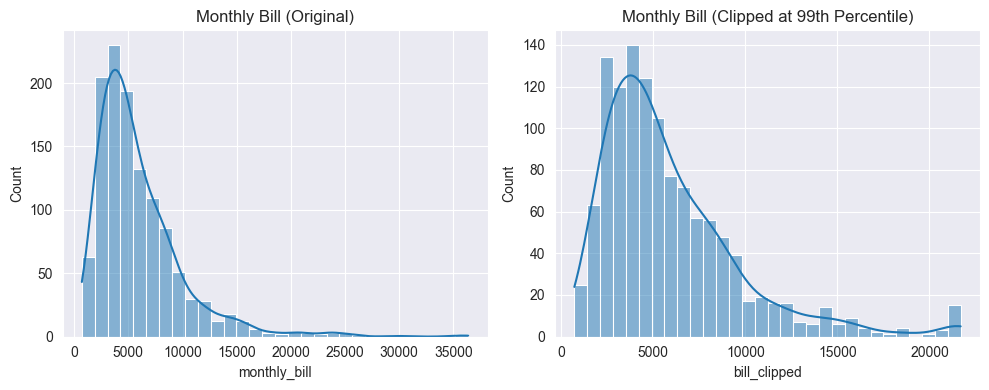

In [29]:
# Set the size of the overall figure
plt.figure(figsize=(10, 4))

# Create the first plot: 1 row, 2 columns, position 1
plt.subplot(1, 2, 1)

# Plot the original monthly bill distribution
# kde=True adds a smooth density curve
# bins=30 divides the data into 30 groups
sns.histplot(
    df["monthly_bill"],
    kde=True,
    bins=30
)
# Add a title 
plt.title("Monthly Bill (Original)")

# Create the second plot: 1 row, 2 columns, position 2
plt.subplot(1, 2, 2)

# Plot the monthly bill after clipping 
sns.histplot(
    df["bill_clipped"],
    kde=True,
    bins=30
)
# Add a title 
plt.title("Monthly Bill (Clipped at 99th Percentile)")

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

# 4.3 Winsorization

In [30]:
# import library
from scipy.stats.mstats import winsorize

In [31]:
# winsorize: cap only the top 10% data
df["bill_winsor"] = winsorize(
    df["monthly_bill"], limits = [0.01, 0.01])

In [32]:
# check effect on extreme values
df.loc[
    [df["monthly_bill"].idxmin(),
     df["monthly_bill"].idxmax()],
    ["bill_winsor"]
]

,bill_winsor
893,1140.0
968,21682.0


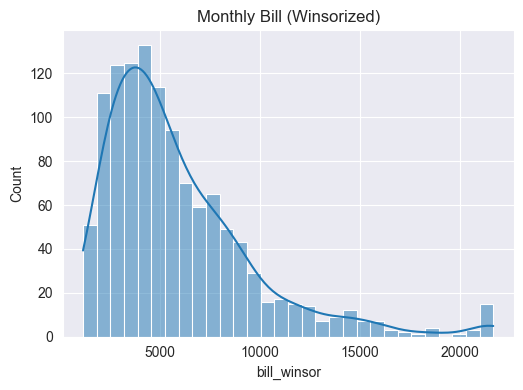

In [36]:
# plot
plt.figure(figsize = (10, 4))
plt.subplot(1,2,2)
sns.histplot(df["bill_winsor"], 
            kde = True, bins = 30)
plt.title("Monthly Bill (Winsorized)")
plt.tight_layout()
plt.show()